# Schematic

Notebook to produce the schematic figure for numerical mixing within a grid cell in the water mass transformation framework.

In [2]:
tub_output_dir = "/g/data/e14/jb2381/anu-tub/outputs"
if pwd() != tub_output_dir 
    cd(tub_output_dir)
end
include("plotting.jl")

  Activating project at `/g/data/e14/jb2381/anu-tub/outputs`
[ Info: Plotting and analysis environment setup!
┌ Info: Experiments in the catalogue are: ["zstar-weaker-KD", "alt-hycom-weaker-KD", "alt-hycom", "hycom1-weaker-KD", "zstar", "adapt", "adapt-weaker-KD", "hycom1"]
│       Available data is:
│       - monthly
│       - monthlyz
│       - monthlyrho2
│       - static
└       - vertical coordinate
┌ Info: Analysis files available:
│       - vgrids: /g/data/e14/jb2381/anu-tub/outputs/vertical_grids.jld2
│       - model_states: /g/data/e14/jb2381/anu-tub/outputs/model_states.jld2
└       - variance_production_025: /g/data/e14/jb2381/anu-tub/outputs/variance_production_025.jld2


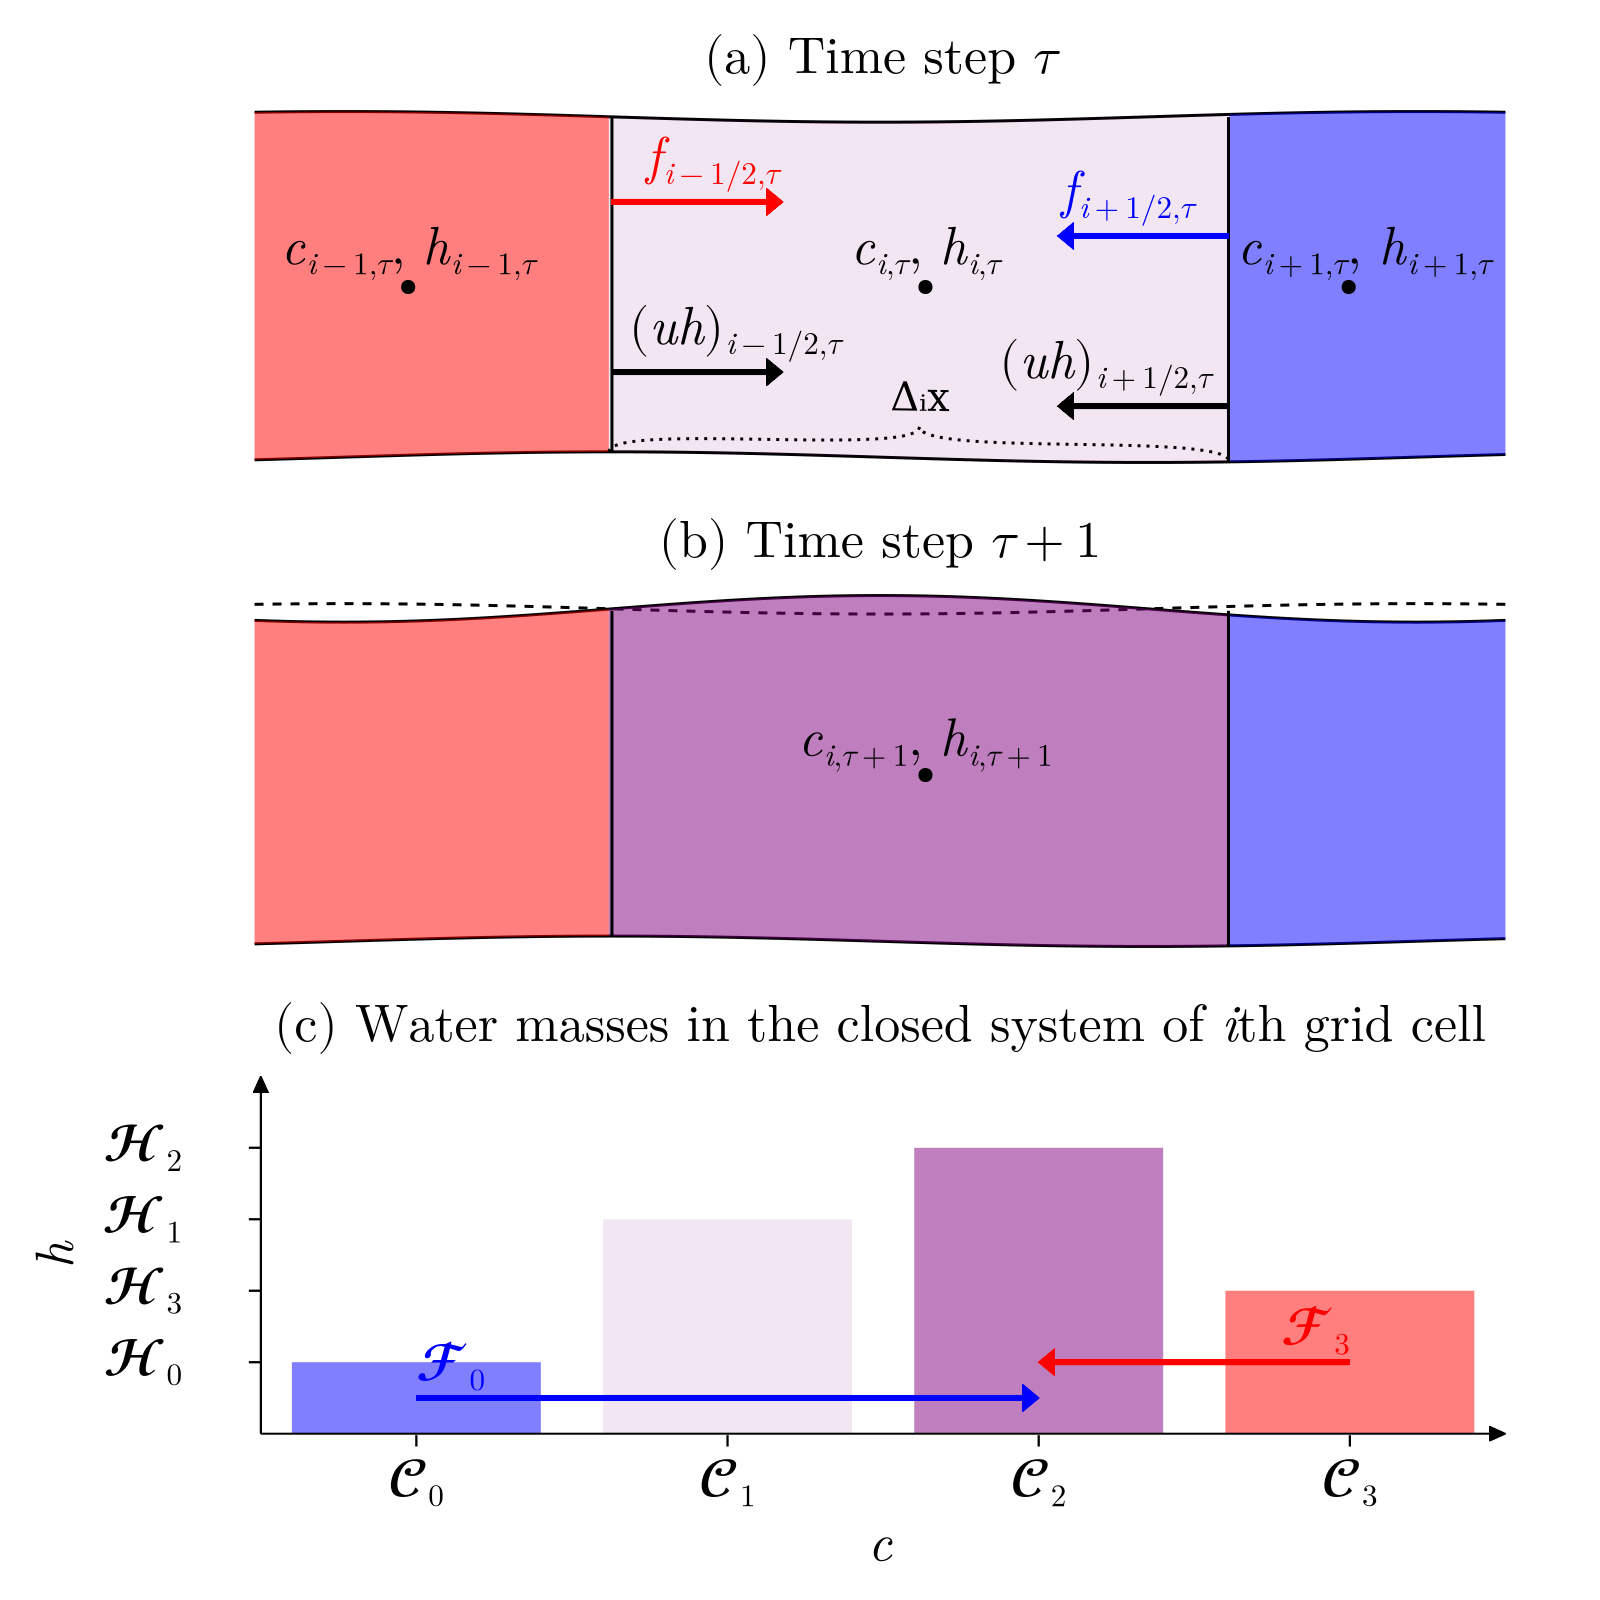

In [3]:
titlesize = fontsize = 26
markersize = 10
fig = Figure(size = (800, 800))

# Initial state
ax1 = Axis(fig[1, 1], title = L"(a) Time step $\tau$"; titlesize)

N = 400
x_range = LinRange(0-π/6, 2π+π/6, N)

scale = 0.125^2
y_upper = 1 .+ scale*cos.(x_range)
y_lower = scale*sin.(x_range)

cell1 = π / 2
find_cell1 = findall(x_range .< cell1)
cell3 = 3.3π / 2
find_cell3 = findall(x_range .> cell3)
find_middle = find_cell1[end]:find_cell3[1]
xmiddle = findall(cell1 .< x_range .< cell3)

# Lines and bands
lines!(ax1, x_range, y_lower, color = :black)
lines!(ax1, x_range, y_upper, color = :black)
band!(ax1, x_range[find_cell1], y_lower[find_cell1], y_upper[find_cell1], color = (:red, 0.5))
band!(ax1, x_range[find_middle], y_lower[find_middle], y_upper[find_middle], color = (:purple, 0.1))
band!(ax1, x_range[find_cell3], y_lower[find_cell3], y_upper[find_cell3], color = (:blue, 0.5))
vlines!(ax1, cell1, ymin = 0.072, ymax = 0.94, color = :black)
vlines!(ax1, cell3, ymin = 0.045, ymax = 0.94, color = :black)
# lines!(ax1, x_range[xmiddle], -ones(length(xmiddle)), color = :black)
bracket!(ax1, x_range[find_cell1[end]], y_lower[find_cell1[end]], x_range[find_cell3[1]], y_lower[find_cell3[1]], text = "Δᵢx", linestyle = :dot)

# Scatter points and labels
offset_for_centre = 15 # to offset scattter points and labels
scatter!(ax1, x_range[Int64(N / 8)], 0.5; markersize, color = :black)
scatter!(ax1, x_range[Int64(N / 2 + offset_for_centre)], 0.5; markersize, color = :black)
scatter!(ax1, x_range[Int64(7N / 8)], 0.5; markersize, color = :black)
text_above_scatter = 0.02
text!(ax1, x_range[Int64(N / 8)], 0.5 + text_above_scatter; text = L"c_{i-1, \tau},~h_{i-1, \tau}", align = (:center, :bottom), fontsize)
text!(ax1, x_range[Int64(N / 2 + offset_for_centre)], 0.5 + text_above_scatter; text = L"c_{i, \tau},~h_{i, \tau}", align = (:center, :bottom), fontsize)
text!(ax1, x_range[Int64(7.1N / 8)], 0.5 + text_above_scatter; text = L"c_{i+1, \tau},~h_{i+1, \tau}", align = (:center, :bottom), fontsize)

# Left side arrows and labels
text_above_arrow_offset = 0.03
arrows2d!(ax1, [cell1], [0.75], [1], [0], color = :red)
text!(ax1, cell1 + 0.2, 0.75 + text_above_arrow_offset; text = L"f_{i - 1/2, \tau}", align = (:left, :bottom), fontsize, color = :red)
arrows2d!(ax1, [cell1], [0.25], [1], [0], color = :black)
text!(ax1, cell1 + 0.1, 0.25 + text_above_arrow_offset; text = L"(uh)_{i - 1/2, \tau}", align = (:left, :bottom), fontsize, color = :black)

# Right side arrows and labels
arrows2d!(ax1, [cell3], [0.65], [-1], [0], color = :blue)
text!(ax1, cell3 - 0.2, 0.65 + text_above_arrow_offset; text = L"f_{i + 1/2, \tau}", align = (:right, :bottom), fontsize, color = :blue)
arrows2d!(ax1, [cell3], [0.15], [-1], [0], color = :black)
text!(ax1, cell3 - 0.1, 0.15 + text_above_arrow_offset; text = L"(uh)_{i + 1/2, \tau}", align = (:right, :bottom), fontsize, color = :black)

hidedecorations!(ax1)
hidespines!(ax1)

# after advection
ax2 = Axis(fig[2, 1], title = L"(b) Time step $\tau + 1$"; titlesize)

y_upper2 = 1 .+ 0.2^2*sin.(x_range .- π/2)

lines!(ax2, x_range, y_lower, color = :black)
lines!(ax2, x_range, y_upper, color = :black, linestyle = :dash)
lines!(ax2, x_range, y_upper2, color = :black)
band!(ax2, x_range[find_cell1], y_lower[find_cell1], y_upper2[find_cell1], color = (:red, 0.5))
band!(ax2, x_range[find_middle], y_lower[find_middle], y_upper2[find_middle], color = (:purple, 0.5))
band!(ax2, x_range[find_cell3], y_lower[find_cell3], y_upper2[find_cell3], color = (:blue, 0.5))
vlines!(ax2, cell1, ymin = 0.072, ymax = 0.915, color = :black)
vlines!(ax2, cell3, ymin = 0.045, ymax = 0.915, color = :black)

# scatter points and labels
scatter!(ax2, x_range[Int64(N / 2 + offset_for_centre)], 0.5; markersize, color = :black)
text!(ax2, x_range[Int64(N / 2 + offset_for_centre)], 0.51; text = L"c_{i, \tau + 1},~h_{i, \tau + 1}", align = (:center, :bottom), fontsize)

hidedecorations!(ax2)
hidespines!(ax2)

# barplot
clabels = [L"\mathcal{C}_{%$(i)}" for i ∈ 0:3]
Hlabels = [L"\mathcal{H}_{%$(i)}" for i ∈ 0:3]
Flabels = [L"\mathcal{F}_{%$(i)}" for i ∈ 0:3]
locations = 1:4
heights = [1, 2, 2.5, 1.5] .- 0.5
axbp = Axis(fig[3, 1]; title = L"(c) Water masses in the closed system of $i$th grid cell", titlesize,
            xlabel = L"c",
            xlabelsize = fontsize,
            xticks = (locations, clabels),
            xticklabelsize = fontsize,
            ylabel = L"h",
            ylabelsize = fontsize,
            yticks = (heights, Hlabels),
            yticklabelsize = fontsize,
            ylabelpadding = 10)
colors = [(:blue, 0.5), (:purple, 0.1), (:purple, 0.5), (:red, 0.5)]
# colors = [:blue, :purple, :purple, :red]
# concentration and thicknesses
bp = barplot!(axbp, locations, heights; colormap = Makie.Categorical(colors), color = 1:4)
# bp = barplot!(axbp, locations, heights; color = colors)
ylims!(axbp, -0.1, 2.6)
hidedecorations!(axbp, ticklabels = false, label = false)
hidespines!(axbp)

# Fluxes
arrows2d!(axbp, [locations[1]], [heights[1] - 0.25], [2], [0], color = :blue)
text!(axbp, locations[1], 0.26; fontsize, text = Flabels[1], color= :blue, align = (:left, :bottom))
arrows2d!(axbp, [locations[end]], [heights[end]-0.5], [-1], [0], color = :red)
text!(axbp, locations[end], 0.51; fontsize, text = Flabels[end], color= :red, align = (:right, :bottom))

# draw axes
arrows2d!(axbp, [0.5], [0], [4], [0], shaftwidth = 1, tipwidth = 8)
arrows2d!(axbp, [0.5], [0], [0], [2.5], shaftwidth = 1, tipwidth = 8)
scatter!(axbp, locations, 0 .* locations .- 0.05, color = :black, marker = :vline)
scatter!(axbp, 0 * heights .+ 0.5 .- 0.02, heights, color = :black, marker = :hline)

# coloubar
# colorbar(fig[1:2, 2], bp, label = L"concentration $(c)$", labelsize = fontsize,
#          ticks = ([1, 2, 3, 4], ["Low", "Low", "High", "High"]))
        # ticks = [0, 5], ticklabels = ["Low", "", "", "High"])
# colorbar(fig[1:2, 2], bp, label = L"concentration $(c)$", labelsize = fontsize,
#          ticklabelsvisible = false, ticksvisible = false, width = 15)
fig

In [4]:
save("FiguresPaper1/schematic.png", fig)